<a href="https://colab.research.google.com/github/geun-hyoung/python-textmining-understanding_shs/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setting

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install nltk
!pip install -U pandas-profiling
!pip install pydantic
!pip install umap-learn
!pip install factor_analyzer
!pip install typing-extensions --upgrade
!pip install kneed
!pip install spacy
!pip install xlsxwriter

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.9/357.9 kB 41.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 65.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 43.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 39.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 99.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27080 sha256=4138c7d60dc8429d882c4c4583f602af52a873a756397695daefd4bf448098ba
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting uninstall: seaborn
    Found existing installation: seabo

In [2]:
import re
import string
from string import punctuation
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from collections import Counter

from scipy.sparse import csr_matrix

from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA, LatentDirichletAllocation, NMF,TruncatedSVD
from sklearn.feature_selection import chi2, f_classif, SelectKBest
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, normalize

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English

import seaborn as sns

from wordcloud import WordCloud

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import TreebankWordTokenizer, word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

from textblob import Word

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
origin_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/train_data.csv")
print("초기 문서 수 :", origin_data.shape[0])

초기 문서 수 : 3840


## STEP 1 : Data Cleaning


In [4]:
origin_data.drop_duplicates(subset=['Article Title', 'Abstract'], inplace=True)
print("중복 제거 후 Document 수 :", origin_data.shape[0])

origin_data.dropna(subset=['Abstract', 'Article Title'], inplace=True)
print("결측치 제거 후 Document 수 :", origin_data.shape[0])

중복 제거 후 Document 수 : 3837
결측치 제거 후 Document 수 : 3833


In [5]:
def combine_columns(*kwargs):
    result = ""

    for sth in kwargs:
        if not pd.isna(sth):
            result += " " + str(sth)

    return result

origin_data["text"] = origin_data.apply(lambda x: combine_columns(x['Article Title'], x['Abstract'], x['Author Keywords']), axis=1)
df = origin_data.loc[:, ['text', 'Article Title']]

print("Data Transformation 후 Document 수 :", df.shape[0])

Data Transformation 후 Document 수 : 3833


### Data preprocessing

In [6]:
custom_nolema = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_rule_1(lemmatization).csv")
custom_stopwords = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_rule_2(stopwords).csv")

custom_nolema = list(custom_nolema['nolema'])
stop_words = stop_words.union(list(custom_stopwords['Stopwords']))

punctuations = list(punctuation)

In [7]:
custom_nolema = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_rule_1(lemmatization).csv")
custom_stopwords = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_rule_2(stopwords).csv")

custom_nolema = list(custom_nolema['nolema'])
stop_words = stop_words.union(list(custom_stopwords['Stopwords']))

punctuations = list(punctuation)

def preprocess_text(text):
    # tokenization
    tokens = word_tokenize(text)

    # check specific problem(i.e., do not lemmatize)
    changed, filtered_tokens = [], []
    wordnet_lemmatizer = WordNetLemmatizer()

    for word in tokens:
        # remove numbers
        word = re.sub(r'\d+', '', word)

        # remove words with length less than 2
        if len(word) < 2:
            continue

        temp_word = word.lower()

        # lemmatization using TextBlob
        lemma_word = Word(temp_word).lemmatize() if temp_word not in custom_nolema else temp_word

        if temp_word != lemma_word:
            changed.append({temp_word: lemma_word})

        filtered_tokens.append(lemma_word)

    filtered_tokens = [word for word in filtered_tokens if word not in stop_words and word not in punctuations]
    processed_text = ' '.join([token for token in filtered_tokens])

    return processed_text, changed

df['corpus'], df['lemma_pairs'] = zip(*df['text'].apply(preprocess_text))
df.drop(columns=['text'], inplace=True)
df.head()

,Article Title,corpus,lemma_pairs
0,HyDSMaaS: A Hybrid Communication Infrastructur...,hydsmaas hybrid communication infrastructure l...,"[{'as': 'a'}, {'problems': 'problem'}, {'consu..."
1,Optimal operating scheme of neighborhood energ...,optimal operating scheme neighborhood energy s...,"[{'communities': 'community'}, {'cities': 'cit..."
2,A Smart Optimization of Fault Diagnosis in Ele...,smart optimization fault diagnosis electrical ...,"[{'demands': 'demand'}, {'years': 'year'}, {'u..."
3,IIoT: Traffic Data Flow Analysis and Modeling ...,iiot traffic data flow analysis modeling exper...,"[{'devices': 'device'}, {'things': 'thing'}, {..."
4,Privacy-Preserved Behavior Analysis and Fall D...,privacy-preserved behavior analysis fall detec...,"[{'sensors': 'sensor'}, {'sequences': 'sequenc..."


In [8]:
df = df.loc[:, ['corpus', 'Article Title']]
df.drop(df[(df['corpus'] == "")].index, inplace=True) # corpus 남아있지 않은 row 삭제

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print("전처리 후 Document 갯수:",tfidf_matrix.shape[0])
print("전처리 후 초기 word-feature 갯수:",tfidf_matrix.shape[1])

전처리 후 Document 갯수: 3833
전처리 후 초기 word-feature 갯수: 16274


##### pilot study



In [9]:
# check_list = df.loc[:, ['lemma_pairs']]
# combined_list = check_list['lemma_pairs'].sum()

# keys, values = [], []

# for d in combined_list:
#     for key, value in d.items():
#         keys.append(key)
#         values.append(value)

# checks = pd.DataFrame({'Key': keys, 'Value': values})
# checks.drop_duplicates(subset=['Key'], inplace=True)
# checks.drop_duplicates(subset=['Value'], inplace=True)

# checks

# def check_meaning(row):
#     key_word = Word(row['Key']).definitions
#     value_word = Word(row['Value']).definitions

#     if key_word and value_word:
#         if key_word[0] != value_word[0]:
#             return (True, f"'{row['Key']}': {key_word[0]}", f"'{row['Value']}': {value_word[0]}")

#     return (False, None, None)


# checks['is_different'], checks['key_def'], checks['value_def'] = zip(*checks.apply(check_meaning, axis=1))
# different_checks = checks[checks['is_different']]
# different_checks.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized(not_lemmatize).csv', index=False)

## STEP 2 : Word-featuring

### 1. Deciding on the number of keywords to be selected from each item

In [ ]:
# visualization function
def plot_keywords(x, y, y_label, title):

    plt.style.use('seaborn-whitegrid')
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.gca().set_facecolor('lightgray')
    plt.grid(color='white', linestyle='-', linewidth=1)

    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    plt.xlabel('Number of selected top keywords from each data')
    plt.ylabel(y_label)

    for i in [3, 4, 5, 6]:
        if i in x:
            index = x.index(i)
            plt.plot(i, y[index], marker='o', color='y')

    plt.title(title)
    plt.show()

keyword_counts = list(range(20, 1, -1))
tfidf_matrix_transposed = tfidf_matrix.toarray()

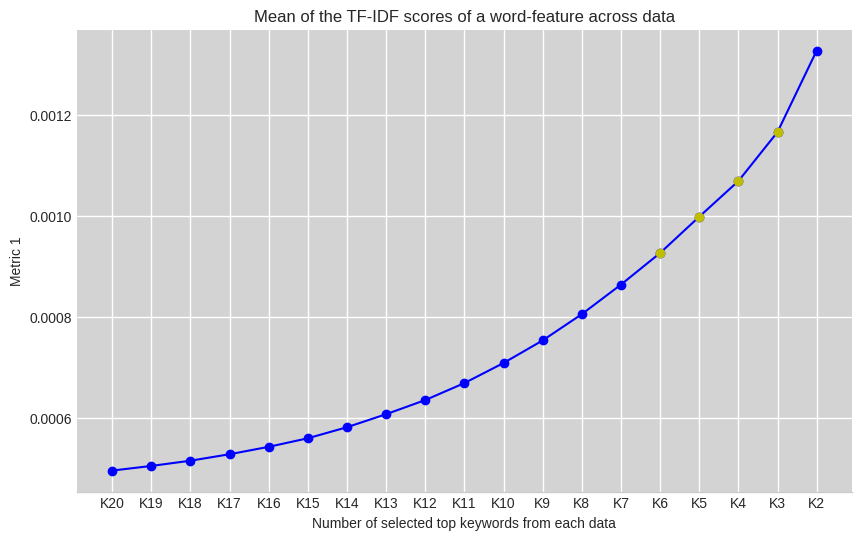

In [ ]:
mean_tfidf_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])
    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()

    # TF-IDF score 평균 계산
    mean_tfidf_score = np.mean(keyword_tfidf_scores)
    mean_tfidf_scores.append(mean_tfidf_score)

plot_keywords(keyword_counts, mean_tfidf_scores, 'Metric 1',  'Mean of the TF-IDF scores of a word-feature across data')

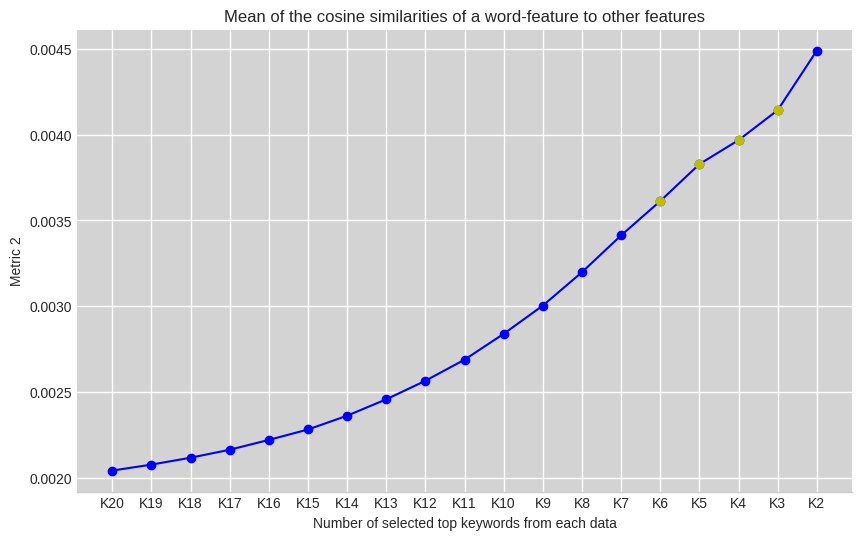

In [ ]:
mean_cosine_similarities = []

for num_keywords in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-num_keywords:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices].T
    cosine_similarities = cosine_similarity(keyword_matrix)

    mean_cosine_similarity = np.mean(cosine_similarities)
    mean_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, mean_cosine_similarities,'Metric 2', 'Mean of the cosine similarities of a word-feature to other features')

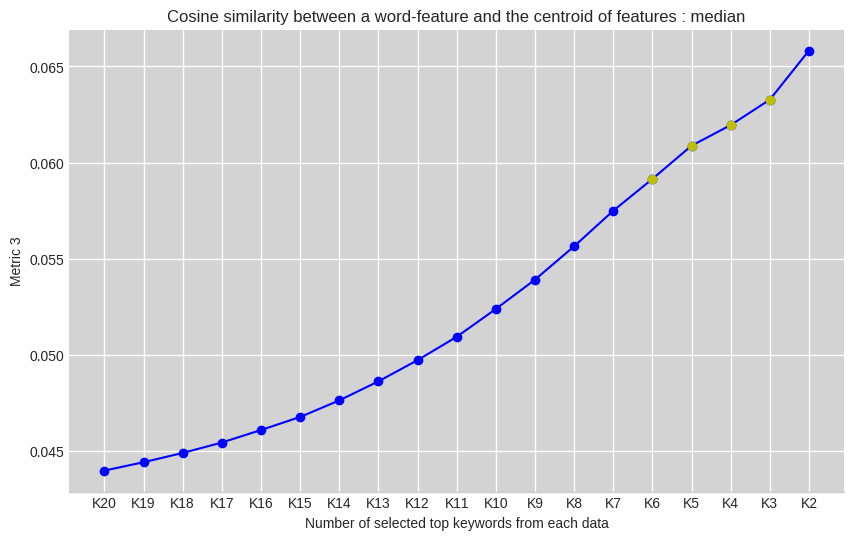

In [ ]:
median_cosine_similarities = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices]

    keyword_matrix = keyword_matrix.T.toarray()

    centroid = np.mean(keyword_matrix, axis=0)
    centroid = np.asarray(centroid).reshape(1, -1)

    cosine_similarities = []

    for idx in range(keyword_matrix.shape[0]):
        word_vector = keyword_matrix[idx, :]
        word_vector = np.asarray(word_vector).reshape(1, -1)
        cosine_similarity_value = cosine_similarity(word_vector, centroid)
        cosine_similarities.append(cosine_similarity_value[0][0])


    mean_cosine_similarity = np.mean(cosine_similarities)
    median_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, median_cosine_similarities, "Metric 3", "Cosine similarity between a word-feature and the centroid of features : median")

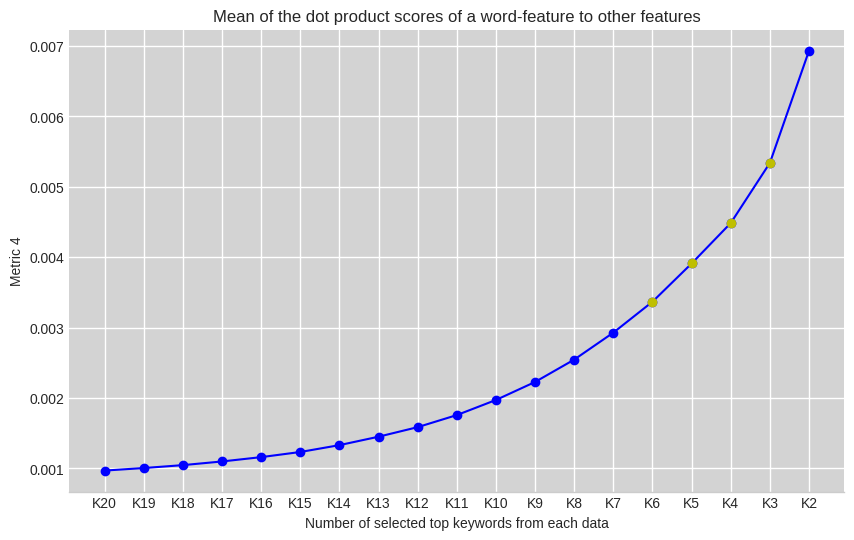

In [ ]:
mean_dot_product_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()
    dot_product_scores = np.dot(keyword_tfidf_scores.T, keyword_tfidf_scores)

    mean_dot_product_score = np.mean(dot_product_scores)
    mean_dot_product_scores.append(mean_dot_product_score)

plot_keywords(keyword_counts, mean_dot_product_scores,"Metric 4", "Mean of the dot product scores of a word-feature to other features")

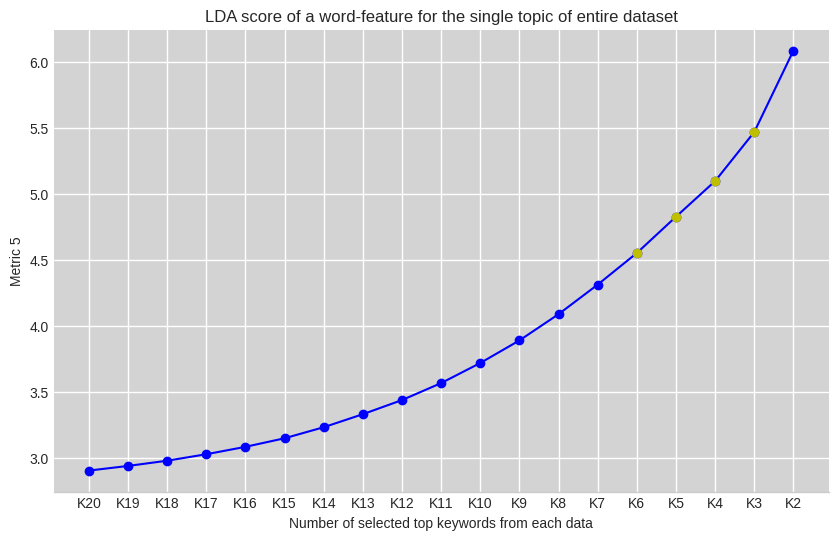

In [ ]:
mean_lda_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))
    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices].toarray()

    num_topics = 1
    lda_model = LatentDirichletAllocation(n_components=num_topics)
    lda_model.fit(keyword_matrix)

    lda_scores = lda_model.components_

    mean_lda_score = np.mean(lda_scores)
    mean_lda_scores.append(mean_lda_score)

plot_keywords(keyword_counts, mean_lda_scores,"Metric 5", "LDA score of a word-feature for the single topic of entire dataset")

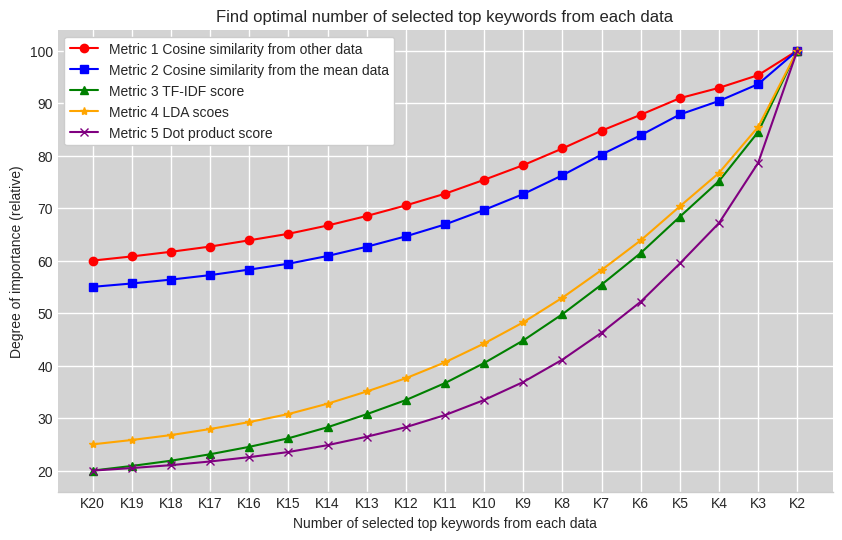

In [ ]:
metric1_values = median_cosine_similarities
metric2_values = mean_cosine_similarities
metric3_values = mean_tfidf_scores
metric4_values = mean_lda_scores
metric5_values = mean_dot_product_scores

metric1_normalized = (metric1_values - np.min(metric1_values)) / (np.max(metric1_values) - np.min(metric1_values)) * 40 + 60
metric2_normalized = (metric2_values - np.min(metric2_values)) / (np.max(metric2_values) - np.min(metric2_values)) * 45 + 55
metric3_normalized = (metric3_values - np.min(metric3_values)) / (np.max(metric3_values) - np.min(metric3_values)) * 80 + 20
metric4_normalized = (metric4_values - np.min(metric4_values)) / (np.max(metric4_values) - np.min(metric4_values)) * 75 + 25
metric5_normalized = (metric5_values - np.min(metric5_values)) / (np.max(metric5_values) - np.min(metric5_values)) * 80 + 20

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().invert_xaxis()

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().set_facecolor('lightgray')

plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

plt.gca().xaxis.set_major_formatter(k_formatter)
plt.grid(color='white', linestyle='-', linewidth=1)
plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')

plt.plot(keyword_counts, metric1_normalized, marker='o', label='Metric 1 Cosine similarity from other data', color='red')
plt.plot(keyword_counts, metric2_normalized, marker='s', label='Metric 2 Cosine similarity from the mean data', color='blue')
plt.plot(keyword_counts, metric3_normalized, marker='^', label='Metric 3 TF-IDF score', color='green')
plt.plot(keyword_counts, metric4_normalized, marker='*', label='Metric 4 LDA scoes', color='orange')
plt.plot(keyword_counts, metric5_normalized, marker='x', label='Metric 5 Dot product score', color='purple')

plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')
plt.title('Find optimal number of selected top keywords from each data')
plt.legend(frameon = True, framealpha=1)

plt.show()

In [ ]:
# Items 당 상위 4개의 단어 선택 - Type 3 제거
top_keywords_per_document = []
feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(len(df)):
    tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray()[0])
    sorted_tfidf_scores = sorted(tfidf_scores,key=lambda x: x[1], reverse=True)

    top_keywords_per_document.append([keyword for keyword,_ in sorted_tfidf_scores[:4]])

# 전체 데이터셋에서 적어도 2번 이상 나온 키워드 추출하기 - Type 1 제거
all_keywords=[keyword for document in top_keywords_per_document for keyword in document]
selected_keywords=list(set(keyword for keyword in all_keywords if all_keywords.count(keyword) >=2))

vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 3833
현재 word-feature 갯수: 1820


### 2. Clustering based on Gaussian mixture model (GMM)

In [ ]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)

tfidf_matrix = vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

feature_names = vectorizer.get_feature_names_out()

In [ ]:
print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 3833
현재 word-feature 갯수: 1820


In [ ]:
from collections import defaultdict

tfidf_matrix_transposed = tfidf_matrix.T.toarray()

keyword_frequency = defaultdict(int)

# GMM based Clustering
for i in range(10):

    gmm = GaussianMixture(n_components=100, covariance_type='diag')
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    cluster_counts = df_clustered_keywords['cluster'].value_counts()
    max_data_pointer_cluster_labels = cluster_counts.nlargest(1).index.tolist()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'].isin(max_data_pointer_cluster_labels)]['keyword'].values.tolist()

    for keyword in max_data_pointer_cluster:
        keyword_frequency[keyword] += 1

    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

1번째 시행 클러스터 속 데이터 갯수: 1144
2번째 시행 클러스터 속 데이터 갯수: 1684
3번째 시행 클러스터 속 데이터 갯수: 1173
4번째 시행 클러스터 속 데이터 갯수: 1148
5번째 시행 클러스터 속 데이터 갯수: 1082
6번째 시행 클러스터 속 데이터 갯수: 1137
7번째 시행 클러스터 속 데이터 갯수: 926
8번째 시행 클러스터 속 데이터 갯수: 958
9번째 시행 클러스터 속 데이터 갯수: 1096
10번째 시행 클러스터 속 데이터 갯수: 1069


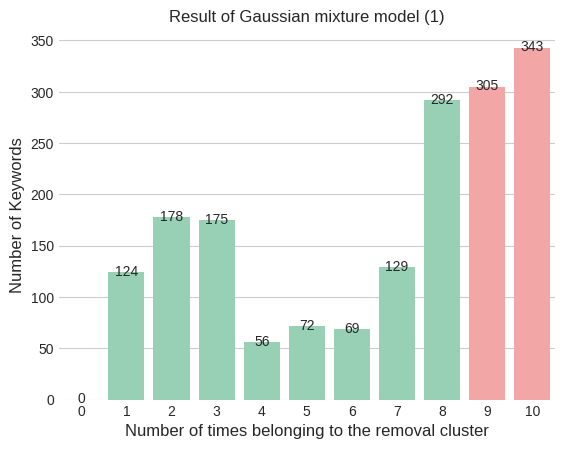

In [ ]:
x = list(range(0, 11))
counts = [len([k for k, v in keyword_frequency.items() if (v >= i) & (v<i+1)]) for i in x]

palette = ["#8fd9b6" if i < 9 else "#ff9999" for i in x]

barplot = sns.barplot(x=x, y=counts, palette=palette)

for idx, val in enumerate(counts):
    barplot.text(idx, val+0.5, val, ha='center', va='center')

plt.title('Result of Gaussian mixture model (1)', fontsize=12)
plt.xlabel('Number of times belonging to the removal cluster', fontsize=12)
plt.ylabel('Number of Keywords', fontsize=12)

sns.despine(left=True, bottom=True)

plt.show()

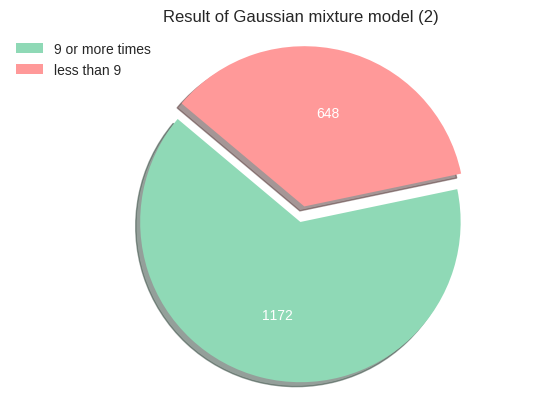

In [ ]:
x = [j for j in range(0, 11)]
counts = []

for i in range(0, 11):
    counts.append(len([k for k, v in keyword_frequency.items() if (v >= i) & (v<i+1)]))

counts[0] = len(selected_keywords) - len(keyword_frequency)

counts_less_than_9 = sum(counts[:9])
counts_more_than_9 = sum(counts[9:])

sizes = [counts_less_than_9, counts_more_than_9]
colors = ['#8fd9b6', '#ff9999']

fig, ax = plt.subplots()
labels = ['9 or more times', 'less than 9']
patches, texts, autotexts = ax.pie(sizes, colors=colors, autopct=lambda p: '{:.0f}'.format(p * sum(sizes) / 100), startangle=140, explode=(0.1, 0), shadow=True)

ax.axis('equal')

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Result of Gaussian mixture model (2)')

ax.legend(patches, labels, loc='upper left', bbox_to_anchor=(-0.1, 1))

plt.show()

In [ ]:
temp_keywords = [k for k, v in keyword_frequency.items() if v >= 9]
core_keywords = [keyword for keyword in selected_keywords if keyword not in temp_keywords]

In [ ]:
vectorizer = TfidfVectorizer(vocabulary=core_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print("Core-word feature Document 갯수:",tfidf_matrix.shape[0])
print("Core-word feature Document word-feature 갯수:",tfidf_matrix.shape[1])

Core-word feature Document 갯수: 3833
Core-word feature Document word-feature 갯수: 1171


In [ ]:
# 최종 핵심 단어 선정
checking_1= pd.DataFrame(core_keywords, columns = ['keyword'])
checking_1.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/core_keyword.csv', index=False)

In [ ]:
# 확인 결과 큰 효과 X
# perform on entire dataset
# tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

# cosine_sim = cosine_similarity(tfidf_df) - np.eye(tfidf_df.shape[0])
# mean_cosine_sim = np.mean(cosine_sim, axis=1)

# df_cosine_sim = pd.DataFrame(mean_cosine_sim, columns=['Mean Cosine Similarity'], index=df.index)
# df_sorted = df_cosine_sim.sort_values(by='Mean Cosine Similarity')

# bottom_100_indices_and_values = df_sorted.head(100)

# bottom_100_titles = df.loc[bottom_100_indices_and_values.index, 'Article Title']
# bottom_100_titles.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/del_document.csv', index=False)

### Result : Word analysis

In [ ]:
from PIL import Image

shs_mask = np.array(Image.open('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/mask.png'))

In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq

path = '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf'

Selecting previously unselected package fonts-nanum.
(Reading database ... 121749 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fonts-nanum-coding (2.5-3) ...
Setting up fonts-nanum-eco (1.000-7) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


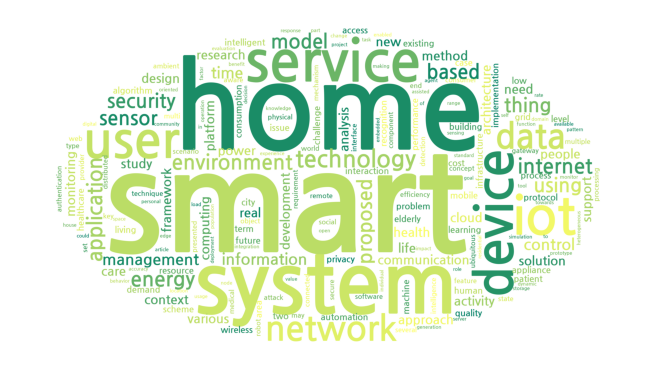

In [ ]:
tfidf = tfidf_matrix
tfidf_array = tfidf.toarray()

tfidf_means = np.mean(tfidf_array, axis=0).reshape(-1, 1)
cosine_sim = cosine_similarity(tfidf_array.T)
cosine_means = np.mean(cosine_sim, axis=0).reshape(-1, 1)

centroid_features = np.mean(tfidf_array.T, axis=0)
cosine_similarities = cosine_similarity(tfidf_array.T, centroid_features.reshape(1, -1))

dot_product = tfidf_array.T.dot(tfidf_array)
dot_product_means = np.mean(dot_product, axis=0).reshape(-1, 1)

lda_model = LatentDirichletAllocation(n_components=1)
lda_model.fit(tfidf_array)
lda_scores = lda_model.components_[0].reshape(-1, 1)

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(np.hstack([tfidf_means, cosine_means, cosine_similarities, dot_product_means, lda_scores]))

keyword_values = np.sum(scaled_values, axis=1)

if np.isnan(keyword_values).any():
    keyword_values = np.nan_to_num(keyword_values)

palettes = ['spring', 'summer', 'seismic','PuBu']

# 워드 클라우드 그리기
wordcloud = WordCloud(background_color ='White',
                      mode="RGB",
                      mask = shs_mask,
                      colormap='summer',
                      width = 800,
                      height = 800,
                      font_path=path,
                      scale=7,stopwords = list(stop_words).append('proposed')).generate_from_frequencies(dict(zip(vectorizer.get_feature_names_out(), keyword_values)))

plt.axis('off')
plt.tight_layout(pad=0)
plt.imshow(wordcloud, interpolation='antialiased')
plt.show()

## STEP 3 : Unsupervised machine learning

In [10]:
# 윗 단계 생략
core_keywords = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/core_keyword.csv")
core_keywords = list(core_keywords['keyword'])

In [11]:
for word in core_keywords:
  if type(word) == float:
      print(core_keywords.index(word))

In [ ]:
del core_keywords[449]

In [12]:
vectorizer = TfidfVectorizer(vocabulary=core_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

### Spectral Clustering

In [ ]:
metrics = ['cosine', 'euclidean']
cluster_range = range(2, 41)

results = {}

for metric in metrics:
    results[metric] = []

    if metric == 'cosine':
        affinity = 'precomputed'
        sim_matrix = cosine_similarity(tfidf_matrix)

    elif metric == 'euclidean':
        affinity = 'precomputed'
        distance_matrix = euclidean_distances(tfidf_matrix)
        sigma = np.mean(distance_matrix)
        sim_matrix = np.exp(-distance_matrix ** 2 / (2.0 * ( sigma ** 2)))

    for n_clusters in cluster_range:
        silhouette_avg_list = []

        # Spectral Clustering
        for _ in range(10):
            sc = SpectralClustering(n_clusters=n_clusters, affinity = affinity).fit(sim_matrix)
            labels=sc.labels_

            silhouette_avg_list.append(silhouette_score(sim_matrix, labels, metric = metric))

        results[metric].append(np.mean(silhouette_avg_list))

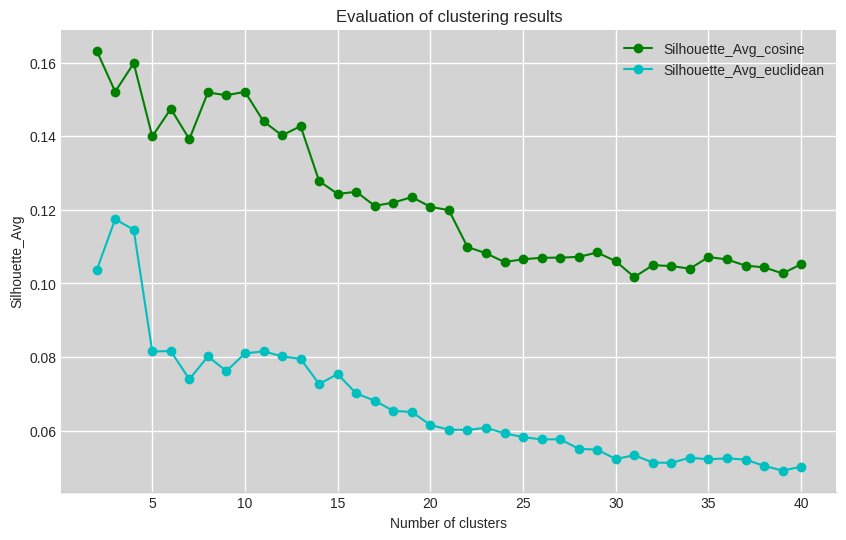

In [ ]:
# spectral clustering 결과
plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.gca().set_facecolor('lightgray')
plt.grid(color='white', linestyle='-', linewidth=1)

for metric in metrics:

    if metric == 'cosine':
        color = 'g'
    elif metric == 'euclidean':
        color = 'c'

    plt.plot(cluster_range, results[metric], label=f'Silhouette_Avg_{metric}', marker='o', color = color)

plt.title('Evaluation of clustering results')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_Avg')
plt.legend()
plt.show()

## STEP 4 : Topic Modeling : Interpreting the clusters

### Topic modeling(NMF & LDA)

In [13]:
import collections
defaultdict = collections.defaultdict

!pip install xlsxwriter

In [14]:
import pandas as pd
from collections import Counter, defaultdict
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import NMF, LatentDirichletAllocation

# 가정: core_keywords, df['corpus'], df['Article Title']가 사전에 정의되어 있음

n_clusters = 13
n_topics = 1
n_top_words = 10

vectorizer = TfidfVectorizer(vocabulary=core_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

sim_matrix = cosine_similarity(tfidf_matrix)

clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42).fit(sim_matrix)
labels = clustering.labels_

nmf = NMF(n_components=n_topics, random_state=0)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)

# 결과를 저장할 데이터프레임 초기화
result_df = pd.DataFrame(columns=['Cluster', 'NMF_Keywords', 'LDA_Keywords'])

for i in range(n_clusters):
    cluster_data = tfidf_matrix[labels == i]

    nmf.fit(cluster_data)
    nmf_topic_words = nmf.components_.argsort()[:, ::-1]
    nmf_keywords = ", ".join([vectorizer.get_feature_names_out()[index] for index in nmf_topic_words[0, :n_top_words]])

    lda.fit(cluster_data)
    lda_topic_words = lda.components_.argsort()[:, ::-1]
    lda_keywords = ", ".join([vectorizer.get_feature_names_out()[index] for index in lda_topic_words[0, :n_top_words]])

    # 클러스터 번호와 함께 키워드를 데이터프레임에 추가
    result_df = result_df.append({'Cluster': i, 'NMF_Keywords': nmf_keywords, 'LDA_Keywords': lda_keywords}, ignore_index=True)

# 엑셀 파일로 저장
writer = pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/topic+modeling(keywords).xlsx', engine='xlsxwriter')
result_df.to_excel(writer, sheet_name='Topic_Modeling', index=False)
writer.save()


### Visualization(Longabaugh, 2012)

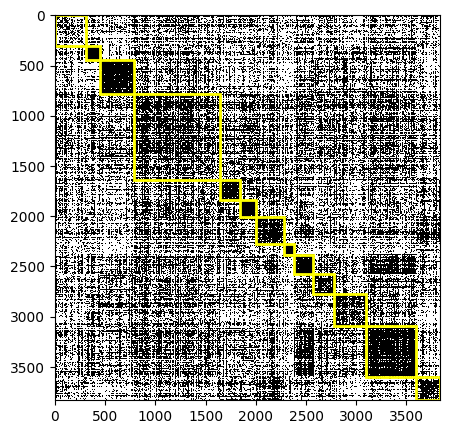

In [15]:
import networkx as nx
from matplotlib import pyplot, patches

cos_sim = cosine_similarity(tfidf_matrix)
mean_sim = np.mean(cos_sim)
threshold = mean_sim * 0.8
binary_adj_matrix = np.where(cos_sim >= threshold, 1, 0)

node_order = np.argsort(labels)
sorted_binary_adj_matrix = binary_adj_matrix[node_order, :][:, node_order]

def draw_adjacency_matrix(G, node_order=None, partitions=[], colors=[]):
    """
    - G is a netorkx graph
    - node_order (optional) is a list of nodes, where each node in G
          appears exactly once
    - partitions is a list of node lists, where each node in G appears
          in exactly one node list
    - colors is a list of strings indicating what color each
          partition should be
    If partitions is specified, the same number of colors needs to be
    specified.
    """
    adjacency_matrix = nx.to_numpy_array(G, dtype=np.bool_, nodelist=node_order)

    #Plot adjacency matrix in toned-down black and white
    fig = pyplot.figure(figsize=(5, 5)) # in inches
    pyplot.imshow(adjacency_matrix,
                  cmap="Greys",
                  interpolation="none")

    # The rest is just if you have sorted nodes by a partition and want to
    # highlight the module boundaries
    assert len(partitions) == len(colors)
    ax = pyplot.gca()
    current_idx = 0
    for partition, color in zip(partitions, colors):
        ax.add_patch(patches.Rectangle((current_idx, current_idx),
                                          len(partition), # Width
                                          len(partition), # Height
                                          facecolor="none",
                                          edgecolor=color,
                                          linewidth=2))
        current_idx += len(partition)

G = nx.from_numpy_array(sorted_binary_adj_matrix)

partitions = []
for i in range(n_clusters):
    partitions.append([idx for idx, cluster in enumerate(labels) if cluster == i])

colors = ['#FFFF00' for _ in range(n_clusters)]
draw_adjacency_matrix(G, partitions=partitions, colors=colors)

### Network analysis

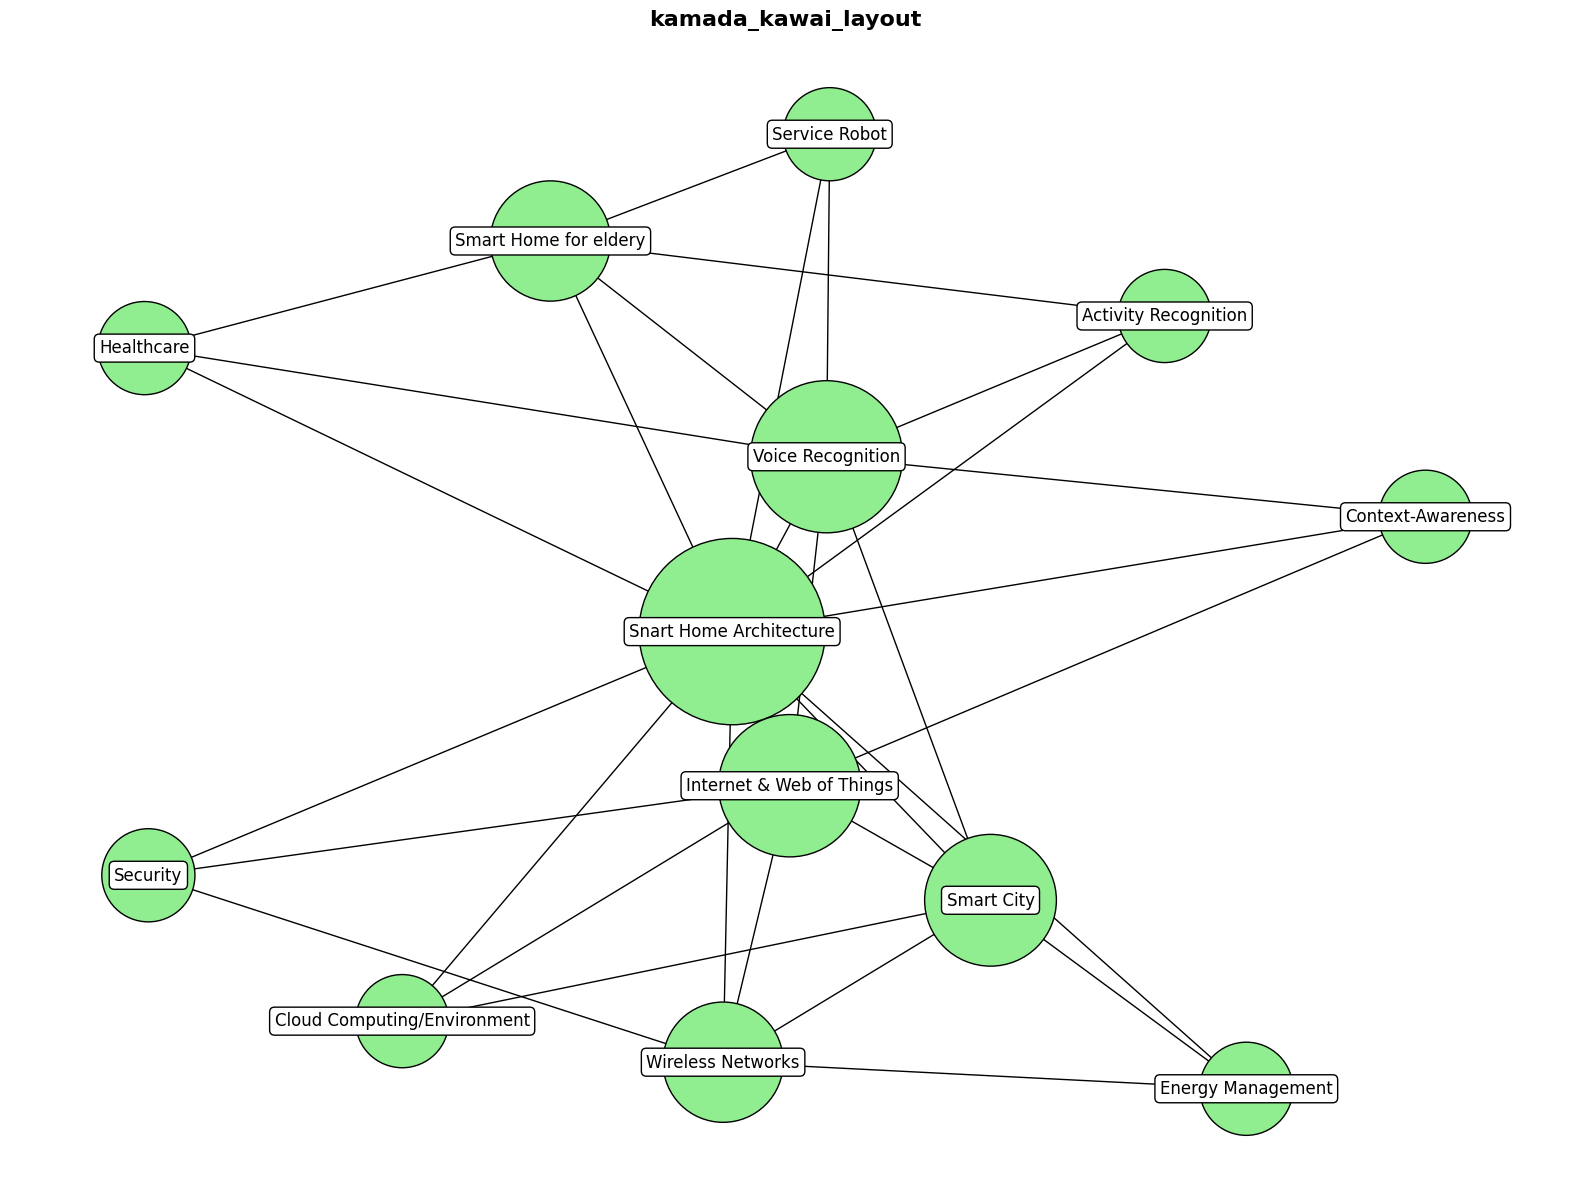

In [27]:
node_names = {
    0: 'Voice Recognition',
    1: 'Security',
    2: 'Energy Management',
    3: 'Snart Home Architecture',
    4: 'Activity Recognition',
    5: 'Context-Awareness',
    6: 'Healthcare',
    7: 'Service Robot',
    8: 'Cloud Computing/Environment',
    9: 'Smart City',
    10: 'Wireless Networks',
    11: 'Internet & Web of Things',
    12: 'Smart Home for eldery'
}

centroids = np.array([np.mean(tfidf_matrix[clustering.labels_ == i].toarray(), axis=0) for i in range(n_clusters)])
similarity_matrix = cosine_similarity(centroids)
top_clusters = {i: sorted(range(len(similarity_matrix[i])), key=similarity_matrix[i].__getitem__, reverse=True)[1:4] for i in range(n_clusters)}
G = nx.Graph()

for cluster, neighbors in top_clusters.items():
    for neighbor in neighbors:
        G.add_edge(cluster, neighbor)

G = nx.relabel_nodes(G, node_names)

node_color = 'lightgreen'
sizes = [G.degree(node) * 1500 for node in G]

def draw_graph(G, layout, node_color, node_sizes, title):
    fig, ax = plt.subplots(figsize=(20, 15))
    pos = layout(G)
    nx.draw(G, pos, with_labels=False, node_size=node_sizes, node_color=node_color, edgecolors='black', font_size=8, font_weight='bold', ax=ax)
    ax.set_title(title, fontsize=16, fontweight='bold')

    for node, (x, y) in pos.items():
        plt.text(x, y, node, fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

    plt.show()

draw_graph(G, lambda G: nx.spring_layout(G, k=0.15), node_color, sizes, 'kamada_kawai_layout')

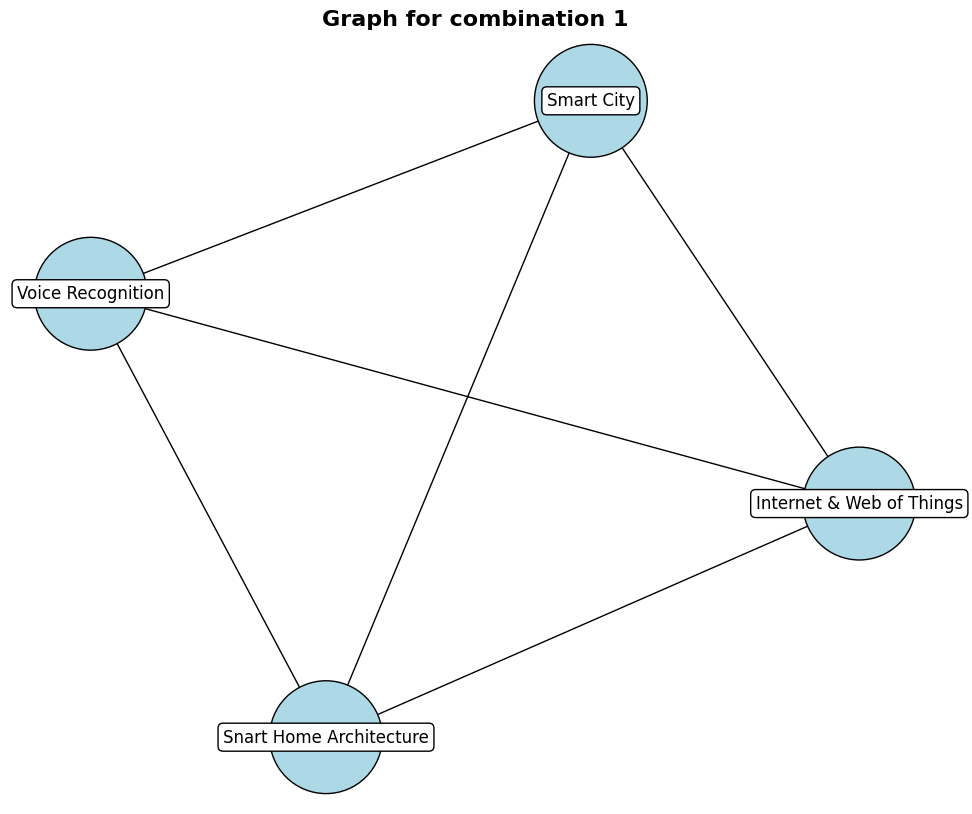

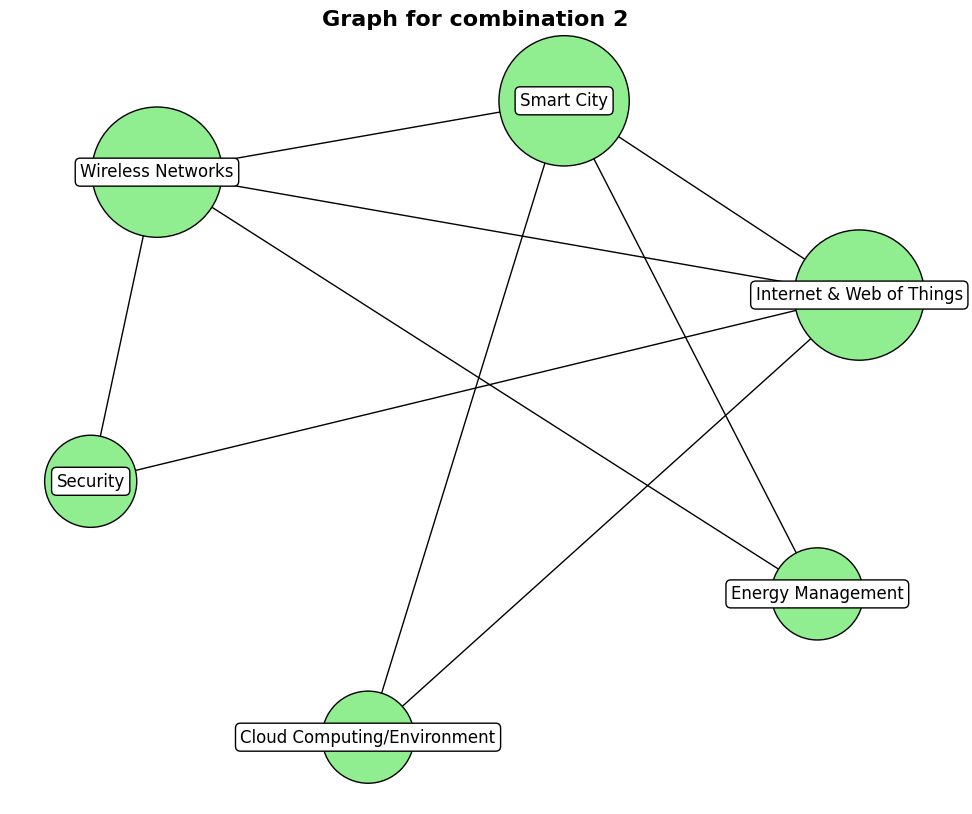

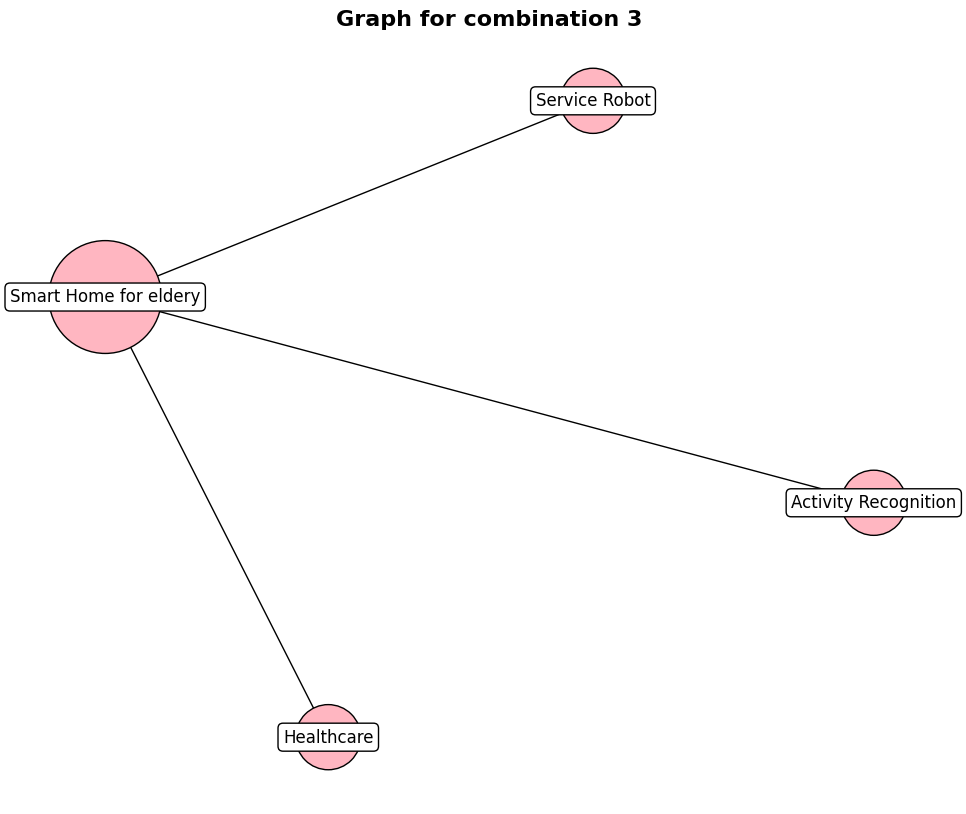

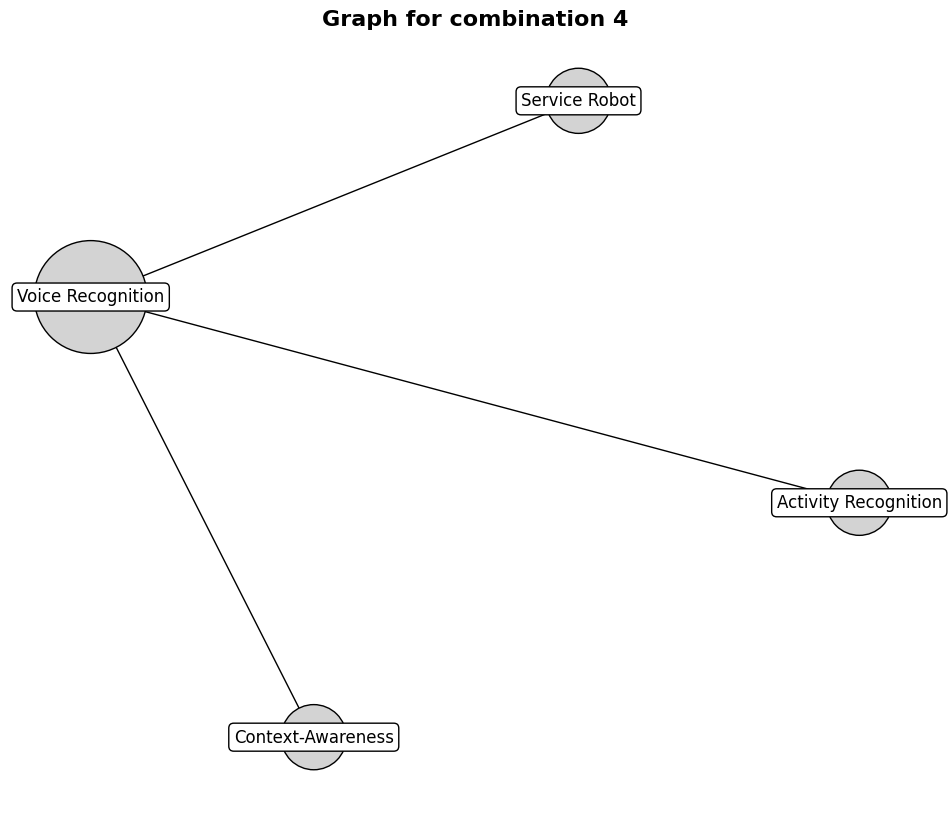

In [46]:
def draw_selected_graph(G, selected_nodes, layout, node_color, title):
    H = G.subgraph(selected_nodes).copy()
    sizes = [H.degree(node) * 2200 for node in H]  # 노드 크기 증가

    fig, ax = plt.subplots(figsize=(12, 10))
    pos = layout(H)
    nx.draw(H, pos, with_labels=False, node_size=sizes, node_color=node_color, edgecolors='black', font_size=8, font_weight='bold', ax=ax)
    ax.set_title(title, fontsize=16, fontweight='bold')

    for node, (x, y) in pos.items():
        plt.text(x, y, node, fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

    plt.show()

colors = ['lightblue', 'lightgreen', 'lightpink', 'lightgray']

combinations = [[0, 3, 9, 11], [1, 2, 8, 9, 10, 11], [4, 6, 7, 12], [0, 4, 5, 7]]

selected_names = [[node_names[i] for i in combo] for combo in combinations]

for i, combo in enumerate(selected_names):
    draw_selected_graph(G, combo, lambda G: nx.spring_layout(G, k=5, seed=42), colors[i], f'Graph for combination {i+1}')  # k 값을 줄여 간격 줄임